# Streamlit App Runthrough

## Setup and Configs

In [3]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from config import set_environment
# for the keys - as explained early in chapter 2
set_environment()

## Document Loader

Imports

In [4]:
import logging
import os
import pathlib
import tempfile
from typing import Any

from langchain_community.document_loaders.epub import UnstructuredEPubLoader
from langchain_community.document_loaders.pdf import PyPDFLoader
from langchain_community.document_loaders.text import TextLoader
from langchain_community.document_loaders.word_document import UnstructuredWordDocumentLoader
from langchain_core.documents import Document

from streamlit.logger import get_logger

logging.basicConfig(encoding="utf-8", level=logging.INFO)
LOGGER = get_logger(__name__)

Class Loaders

In [5]:
class EPubReader(UnstructuredEPubLoader):
    def __init__(self, file_path: str | list[str], **unstructured_kwargs: Any):
        super().__init__(file_path, **unstructured_kwargs, mode="elements", strategy="fast")

class DocumentLoaderException(Exception):
    pass

class DocumentLoader:
    """Loads in a document with a supported extension."""

    supported_extensions = {
        ".pdf": PyPDFLoader,
        ".txt": TextLoader,
        ".epub": EPubReader,
        ".docx": UnstructuredWordDocumentLoader,
        ".doc": UnstructuredWordDocumentLoader,
    }

Load Doc Function

In [6]:
def load_document(temp_filepath: str) -> list[Document]:
    """Load a file and return it as a list of documents.

    Doesn't handle a lot of errors at the moment.
    """
    ext = pathlib.Path(temp_filepath).suffix

    loader = DocumentLoader.supported_extensions.get(ext)
    if not loader:
        raise DocumentLoaderException(
            f"Invalid extention type {ext}, cannot load this type of file"
        )
    
    loaded = loader(temp_filepath)
    docs = loaded.load()
    logging.info(docs)
    return docs

## LLMs

Imports

In [7]:
from langchain.embeddings import CacheBackedEmbeddings
from langchain.storage import LocalFileStore
from langchain_groq import ChatGroq
from langchain_openai import OpenAIEmbeddings

General LLM Setup

In [8]:
chat_model = ChatGroq(
    model="deepseek-r1-distill-llama-70b",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
)

store = LocalFileStore("./cache/")

underlying_embeddings = OpenAIEmbeddings(
    model="text-embedding-3-large",
)

# Avoid unnecessary costs by caching the embeddings.
EMBEDDINGS = CacheBackedEmbeddings.from_bytes_store(
    underlying_embeddings, store, namespace=underlying_embeddings.model
)

/opt/anaconda3/envs/langchain_ai/lib/python3.10/site-packages/langchain/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()


## Retrievers

Imports

In [19]:
import os
import tempfile
from typing import Any

from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.retrievers import BaseRetriever
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_text_splitters import RecursiveCharacterTextSplitter

VECTOR_STORE = InMemoryVectorStore(embedding=EMBEDDINGS)

Retriever class

In [20]:
def split_documents(docs: list[Document]) -> list[Document]:
    """Split each document."""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500, chunk_overlap=200,
    )
    return text_splitter.split_documents(docs)

In [25]:
class DocumentRetriever(BaseRetriever):
    """A retriever that contains the top k documents that contain the user query."""
    documents: list[Document] = []
    k: int = 5

    def model_post_init(self, ctx: Any) -> None:
        self.store_documents(self.documents)

    @staticmethod
    def store_documents(docs: list[Document]) -> None:
        """Add documents to the vector store"""
        splits = split_documents(docs)
        VECTOR_STORE.add_documents(splits)

    def add_uploaded_docs(self, uploaded_files):
        """Add uploaded documents."""
        docs = []
        with tempfile.TemporaryDirectory() as temp_dir:
            for file in uploaded_files:
                temp_filepath = os.path.join(temp_dir, file.name)
                # Write file content first
                with open(temp_filepath, "wb") as f:
                    f.write(file.getvalue())
                # Load document AFTER file is closed
                try:
                    docs.extend(load_document(temp_filepath))
                except Exception as e:
                    print(f"Failed to load {file.name}: {e}")
                    continue

        self.documents.extend(docs)
        self.store_documents(docs)

    def _get_relevant_documents(
            self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> list[Document]:
        """Sync implementations for retriever."""
        if len(self.documents) == 0:
            return []
        return VECTOR_STORE.similarity_search(query=query, k=self.k)

## RAG Component

In [26]:
"""LangGraph for RAG.

CorpDocs with Citations: A Corporate Documentation Pipeline with RAG and Source Attribution
This Single file contains the complete code to run a documentation generation system
using LangChain, langGraph, and Gradio. In addition to generating and refining documentation,
this pipeline now retrieves and attaches citations to the final output.

Workflow Overview:
1. Generate an initial project documentation draft from a user's request.
2. Analyse the draft for compliance with corporate standards.
3. If issues are detected, prompt for LLM feedback.
4. Finalise the documentation (integrating any feedback).
5. Retrieve and append citations to the final document.
6. Output the fully revised document with inline source citations.

Note: More details on performance measurement and observability will be covered in Chapter 8.

"""

"LangGraph for RAG.\n\nCorpDocs with Citations: A Corporate Documentation Pipeline with RAG and Source Attribution\nThis Single file contains the complete code to run a documentation generation system\nusing LangChain, langGraph, and Gradio. In addition to generating and refining documentation,\nthis pipeline now retrieves and attaches citations to the final output.\n\nWorkflow Overview:\n1. Generate an initial project documentation draft from a user's request.\n2. Analyse the draft for compliance with corporate standards.\n3. If issues are detected, prompt for LLM feedback.\n4. Finalise the documentation (integrating any feedback).\n5. Retrieve and append citations to the final document.\n6. Output the fully revised document with inline source citations.\n\nNote: More details on performance measurement and observability will be covered in Chapter 8.\n\n"

Imports

In [27]:
from typing import Annotated

from langchain_core.documents import Document
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import MemorySaver
from langgraph.constants import END
from langgraph.graph import START, StateGraph, add_messages
from typing_extensions import List, TypedDict

Rag Setup and Functions

In [ ]:
system_prompt = (
    "You're a helpful AI assistant. Given a user question "
    "and some corporate document snippets and written documentation. "
    "If none of the documents is relevant to the question, "
    "mention that there's no relevant document, and then "
    "answer the question to the best of your knowledge."
    "\n\nHere are the corporate documents: "
    "{context}"
)

retriever = DocumentRetriever()
prompt = ChatPromptTemplate.from_messages(
    [SystemMessage(system_prompt), HumanMessage("{question}"),]
)

State for application

In [29]:
# State for application
class State(TypedDict):
    question: str
    context: list[Document]
    answer: str
    issues_report: str
    issues_detected: bool
    messages: Annotated[list, add_messages]

Define application steps

In [30]:
def retrieve(state: State):
    retrieved_docs = retriever.invoke(state["messages"][-1].content)
    print(retrieved_docs)
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke(
        {"question": state["messages"[-1].content, "context": docs_content]}
    )
    response = chat_model.invoke(messages)
    print(response.content)
    return {"answer": response.content}

def double_check(state: State):
    result = chat_model.invoke([{
        "role": "user",
        "content": (
            f"Review the following project documentation for compliance with our corporate standards."
            f"Return 'ISSUES FOUND' followed by any issues detected or 'NO ISSUES': {state['answer']}"
        )
    }])

    # Extract actual response (after thinking block)
    content = result.content
    if "</think>" in content:
        actual_response = content.split("</think>", 1)[1].strip()
    else:
        actual_response = content.strip()

    if "ISSUES FOUND" in actual_response:
        print("Issues Detected")
        return {
            "issues_report": actual_response.split("ISSUES FOUND", 1)[1].strip(),
            "issues_detected": True
        }
    
    print("No Issues Detected")
    return {
        "issues_report": "",
        "issues_detected": False,
    }

Finalises documentation by incorporating feedback if available

In [31]:
def doc_finaliser(state: State):
    """Finalise documentation by integrating human feedback"""
    if "issues_detected" in state and state["issues_detected"]:
        response = chat_model.invoke({
            "role": "user",
            "content": (
                f"Revise the following documentation to address these feedback points: {state['issues_report']}\n"
                f"Original Document: {state['answer']}\n"
                f"Always return the full revised document, even if no changes are needed."
            )
        })
        return {
            "messages": [AIMessage(response.content)]
        }
    
    return {
        "messages": [AIMessage(state["answer"])]
    }

In [33]:
graph_builder = StateGraph(State).add_sequence(
    [retrieve, generate, double_check, doc_finaliser]
)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("doc_finaliser", END)
memory = MemorySaver()

graph = graph_builder.compile(checkpointer=memory)
config = {"configurable": {"thread_id": "abc123"}}

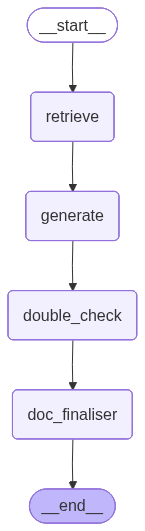

In [36]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Streamlit App

In [44]:
!PYTHONPATH=.. streamlit run streamlit_app.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://10.4.55.77:8501

  For better performance, install the Watchdog module:

  $ xcode-select --install
  $ pip install watchdog
            
/opt/anaconda3/envs/langchain_ai/lib/python3.10/site-packages/langchain/embeddings/cache.py:58: UserWarning: Using default key encoder: SHA-1 is *not* collision-resistant. While acceptable for most cache scenarios, a motivated attacker can craft two different payloads that map to the same cache key. If that risk matters in your environment, supply a stronger encoder (e.g. SHA-256 or BLAKE2) via the `key_encoder` argument. If you change the key encoder, consider also creating a new cache, to avoid (the potential for) collisions with existing keys.
  _warn_about_sha1_encoder()
Failed to load _712020f17141a969294873885bacea25fa08bc-Companies House API Backend Specification-111225-115135.pdf: `pypdf` package not found, please install it with 